<a href="https://www.kaggle.com/code/sahasdubey25/notebook4844a73414?scriptVersionId=256469488" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(84).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(44).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(245).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/6.jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(238).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(196).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(108).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(310).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image (5).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(186).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(29).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(140).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(224).jpg

In [2]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
from PIL import Image
import os

import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training')

['pituitary', 'notumor', 'meningioma', 'glioma']

In [4]:
torch.manual_seed(42)

In [5]:
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [7]:
train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)

In [8]:
print(test_data.classes)
print(train_data.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']
['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
class_names = train_data.classes
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [10]:
train_loader = DataLoader(train_data, batch_size = 32, shuffle = True, drop_last = True)
test_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

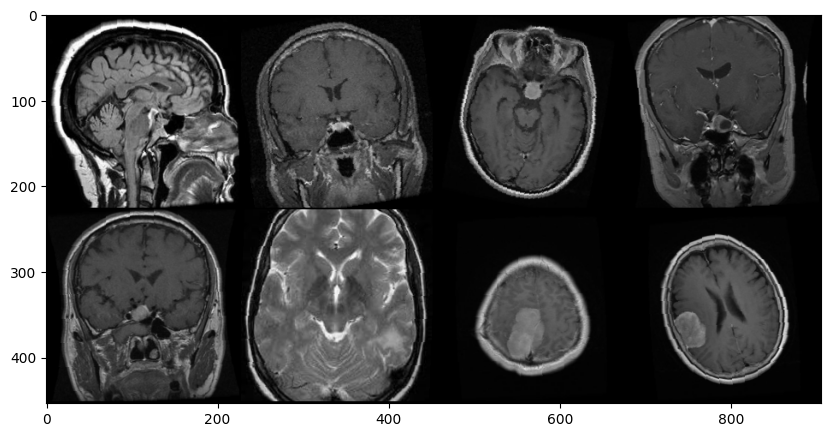

In [11]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
plt.figure(figsize=(10, 8))
plt.imshow(make_grid(images[:8], nrow=4).permute(1, 2, 0))
plt.show()

In [12]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2)    
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)   
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  
        
        self.fc1 = nn.Linear(128*28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 4)  

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)     

        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)     

        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X, 2, 2)     

        X = X.view(-1, 128*28*28)    
        
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)               

        return F.log_softmax(X, dim=1)

In [13]:
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

In [14]:
for param in model.parameters():
    print(param.numel())

2400
32
18432
64
73728
128
25690112
256
32768
128
512
4


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvolutionalNetwork().to(device)

In [16]:
criterion = nn.CrossEntropyLoss()  # For multi-class classification (no need for log_softmax during training if using this)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
import time

epochs = 11
max_trn_batch = 800
max_tst_batch = 300
train_losses = []
test_losses = []
train_correct = []
test_correct = []
start_time = time.time()
total_samples = len(train_loader.dataset)

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    running_train_loss = 0.0
    running_test_loss = 0.0
    test_batches = 0
    train_batches = 0

    
    model.train()
    for b, (X_train, y_train) in enumerate(train_loader):
        if b == max_trn_batch:
            break
        
        
        X_train, y_train = X_train.to(device), y_train.to(device)

        
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        running_train_loss += loss.item()
        train_batches += 1
        
        predicted = torch.max(y_pred, 1)[1]
        trn_corr += (predicted == y_train).sum().item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if b % 25 == 0:
            samples_seen = (b+1) * X_train.size(0)
            percentage = (samples_seen / total_samples) * 100
            accuracy = trn_corr * 100 / samples_seen
            print(f'epoch: {i+1 :2}  batch: {b:4} [{ percentage:6.2f}%]  loss: {loss.item():10.8f}  accuracy: {accuracy:7.2f}%')

    train_losses.append(running_train_loss / train_batches)
    train_correct.append(trn_corr)


    
    model.eval()
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            if b == max_tst_batch:
                break
                
            X_test, y_test = X_test.to(device), y_test.to(device)
            
            y_val = model(X_test)
            loss = criterion(y_val, y_test)
            running_test_loss += loss.item()
            test_batches += 1
            
            predicted = torch.max(y_val, 1)[1]
            tst_corr += (predicted == y_test).sum().item()
            
    test_losses.append(running_test_loss / test_batches)
    test_correct.append(tst_corr)

print(f'\n time taken to train: {(time.time() - start_time)/60:.0f} minutes')

epoch:  1  batch:    0 [  0.56%]  loss: 1.38310635  accuracy:   28.12%
epoch:  1  batch:   25 [ 14.57%]  loss: 0.68983012  accuracy:   51.20%
epoch:  1  batch:   50 [ 28.57%]  loss: 0.69413662  accuracy:   60.60%
epoch:  1  batch:   75 [ 42.58%]  loss: 0.50097454  accuracy:   65.46%
epoch:  1  batch:  100 [ 56.58%]  loss: 0.58638227  accuracy:   68.04%
epoch:  1  batch:  125 [ 70.59%]  loss: 0.29062802  accuracy:   70.14%
epoch:  1  batch:  150 [ 84.59%]  loss: 0.67978626  accuracy:   71.25%
epoch:  1  batch:  175 [ 98.60%]  loss: 0.60319650  accuracy:   72.87%
epoch:  2  batch:    0 [  0.56%]  loss: 0.48948857  accuracy:   78.12%
epoch:  2  batch:   25 [ 14.57%]  loss: 0.52964896  accuracy:   83.05%
epoch:  2  batch:   50 [ 28.57%]  loss: 0.49116749  accuracy:   84.01%
epoch:  2  batch:   75 [ 42.58%]  loss: 0.40059945  accuracy:   84.29%
epoch:  2  batch:  100 [ 56.58%]  loss: 0.21667108  accuracy:   84.41%
epoch:  2  batch:  125 [ 70.59%]  loss: 0.29774255  accuracy:   84.57%
epoch:

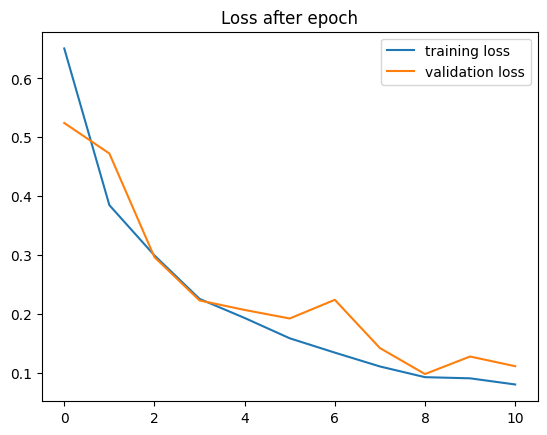

In [18]:
plt.plot(range(epochs),train_losses, label = 'training loss')
plt.plot(range(epochs), test_losses, label= 'validation loss')
plt.title('Loss after epoch')
plt.legend();
plt.show()

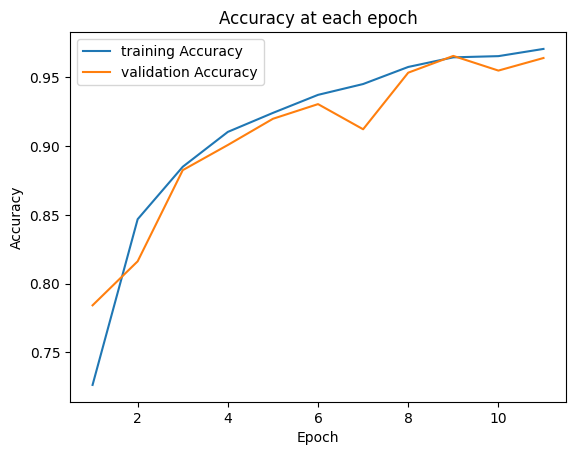

In [19]:
epochs = len(train_correct)


train_acc = [c / len(train_data) for c in train_correct]
val_acc = [c / len(test_data) for c in test_correct]

plt.plot(range(1, epochs + 1), train_acc, label='training Accuracy')
plt.plot(range(1, epochs + 1), val_acc, label='validation Accuracy')
plt.title('Accuracy at each epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [20]:
def calculate_accuracy(model, data_loader, device):
    model.eval()  
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)  
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy
                                                                                                  
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f'Test Accuracy: {test_accuracy:.2f}%')


Test Accuracy: 96.41%


In [21]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

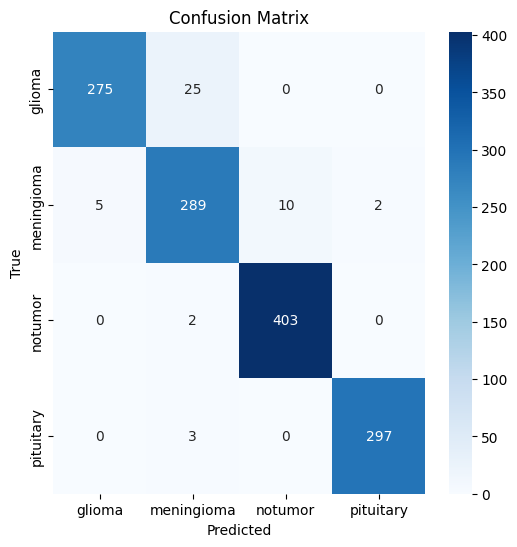

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [23]:
new_data_dir = '/kaggle/input/brain-tumor-classification-mri/Training'
new_dataset = datasets.ImageFolder(root=new_data_dir, transform=test_transforms)
new_loader = torch.utils.data.DataLoader(new_dataset, batch_size=32, shuffle=True)

In [24]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in new_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print("Accuracy on a different picked dataset:", 100 * correct / total)

Accuracy on a different picked dataset: 97.59581881533101


## Now lets try comparing it to another model using transfer learning ##

In [25]:
densenet121 = models.densenet121(pretrained = True)

for param in densenet121.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 144MB/s]


In [26]:
densenet121.classifier = nn.Linear(densenet121.classifier.in_features, 4)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
densenet121 = densenet121.to(device)

In [28]:
torch.manual_seed(101)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(densenet121.classifier.parameters(), lr=0.001, weight_decay=1e-4)
densenet121

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [29]:
epochs = 10
for epoch in range(epochs):
    densenet121.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = densenet121(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f'Epoch: [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc*100:.2f}%')


Epoch: [1/10], Loss: 0.6907, Accuracy: 76.40%
Epoch: [2/10], Loss: 0.4412, Accuracy: 84.80%
Epoch: [3/10], Loss: 0.3824, Accuracy: 86.62%
Epoch: [4/10], Loss: 0.3573, Accuracy: 86.87%
Epoch: [5/10], Loss: 0.3311, Accuracy: 88.06%
Epoch: [6/10], Loss: 0.3280, Accuracy: 87.90%
Epoch: [7/10], Loss: 0.3011, Accuracy: 89.04%
Epoch: [8/10], Loss: 0.2956, Accuracy: 89.22%
Epoch: [9/10], Loss: 0.2876, Accuracy: 89.69%
Epoch: [10/10], Loss: 0.2806, Accuracy: 89.82%


In [30]:
densenet121.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = densenet121(images)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

final_test_acc = test_correct / test_total
print(f'Final Test Accuracy: {final_test_acc*100:.2f}%')


Final Test Accuracy: 86.73%
